In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

print(tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)
np.random.seed(42)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
DATA_DIR = Path("data_processed")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_size = len(val_test_ds) // 2
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

CLASS_NAMES = train_ds.class_names
print(f"Classes: {CLASS_NAMES}")
print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}, Test batches: {len(test_ds)}")

Found 353 files belonging to 3 classes.
Using 283 files for training.
Found 353 files belonging to 3 classes.
Using 70 files for validation.
Classes: ['candy', 'chocolate', 'rice_snack']
Train batches: 36, Val batches: 4, Test batches: 5


In [20]:
factor = 0.2

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor),
        tf.keras.layers.RandomZoom(factor),
        tf.keras.layers.RandomContrast(factor),
        tf.keras.layers.RandomTranslation(factor, factor),
    ]
)

In [21]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [22]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        771 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.3922 - loss: 1.9131 - val_accuracy: 0.4062 - val_loss: 1.1254
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.4912 - loss: 1.7129 - val_accuracy: 0.4688 - val_loss: 1.0902
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5159 - loss: 1.5267 - val_accuracy: 0.5000 - val_loss: 1.1130
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5406 - loss: 1.3745 - val_accuracy: 0.6875 - val_loss: 0.7112
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6219 - loss: 1.2359 - val_accuracy: 0.5000 - val_loss: 1.2501
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6466 - loss: 1.0773 - val_accuracy: 0.5625 - val_loss: 0.9803
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6007 - loss: 1.1755 - val_accuracy: 0.5625 - val_loss: 0.8543
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6572 - loss: 1.0897 - val_accuracy: 0

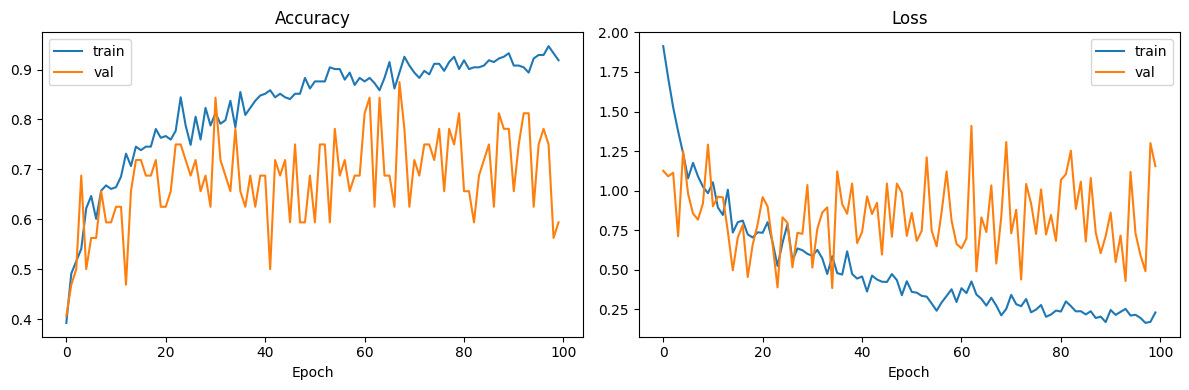

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="val")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="val")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       candy       0.73      0.73      0.73        11
   chocolate       0.55      0.92      0.69        12
  rice_snack       1.00      0.47      0.64        15

    accuracy                           0.68        38
   macro avg       0.76      0.70      0.68        38
weighted avg       0.78      0.68      0.68        38



2026-07-06 12:09:31.805919: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [27]:
model.save('snack_classifier_epoch50.keras')
print(f"Model saved")

Model saved


In [28]:
def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = CLASS_NAMES[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.1%})")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

# 使い方:
# predict_image("path/to/your/snack_image.jpg")

## Phase 2: Fine-tuning

ResNet50 の上位レイヤー（conv5_block）を解凍し、ドメイン固有の特徴を再学習させますわ。

In [29]:
# ResNet50 の conv5_block（最終畳み込みブロック）のみ解凍
FINE_TUNE_AT = 143  # conv5_block1 の開始インデックス

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers in base_model: {trainable_count} / {len(base_model.layers)}")

Trainable layers in base_model: 32 / 175


In [30]:
FINE_TUNE_LR = 1e-5
FINE_TUNE_EPOCHS = 30

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor="val_loss"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/snack_fine_tuned_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        771 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 15,501,315 (59.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [31]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.6714 - loss: 1.3905 - val_accuracy: 0.8438 - val_loss: 0.7079 - learning_rate: 1.0000e-05
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.8657 - loss: 0.5035 - val_accuracy: 0.8125 - val_loss: 0.8127 - learning_rate: 1.0000e-05
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.8693 - loss: 0.3794 - val_accuracy: 0.8750 - val_loss: 0.1765 - learning_rate: 1.0000e-05
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8763 - loss: 0.3731 - val_accuracy: 0.8750 - val_loss: 0.4508 - learning_rate: 1.0000e-05
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8799 - loss: 0.3326 - val_accuracy: 0.8438 - val_loss: 0.5269 - learning_rate: 1.0000e-05
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.8799 - loss: 0.3101 - val_accuracy: 0.8750 - val_loss: 0.3520 - learning_rate: 1.0000e-05
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy:

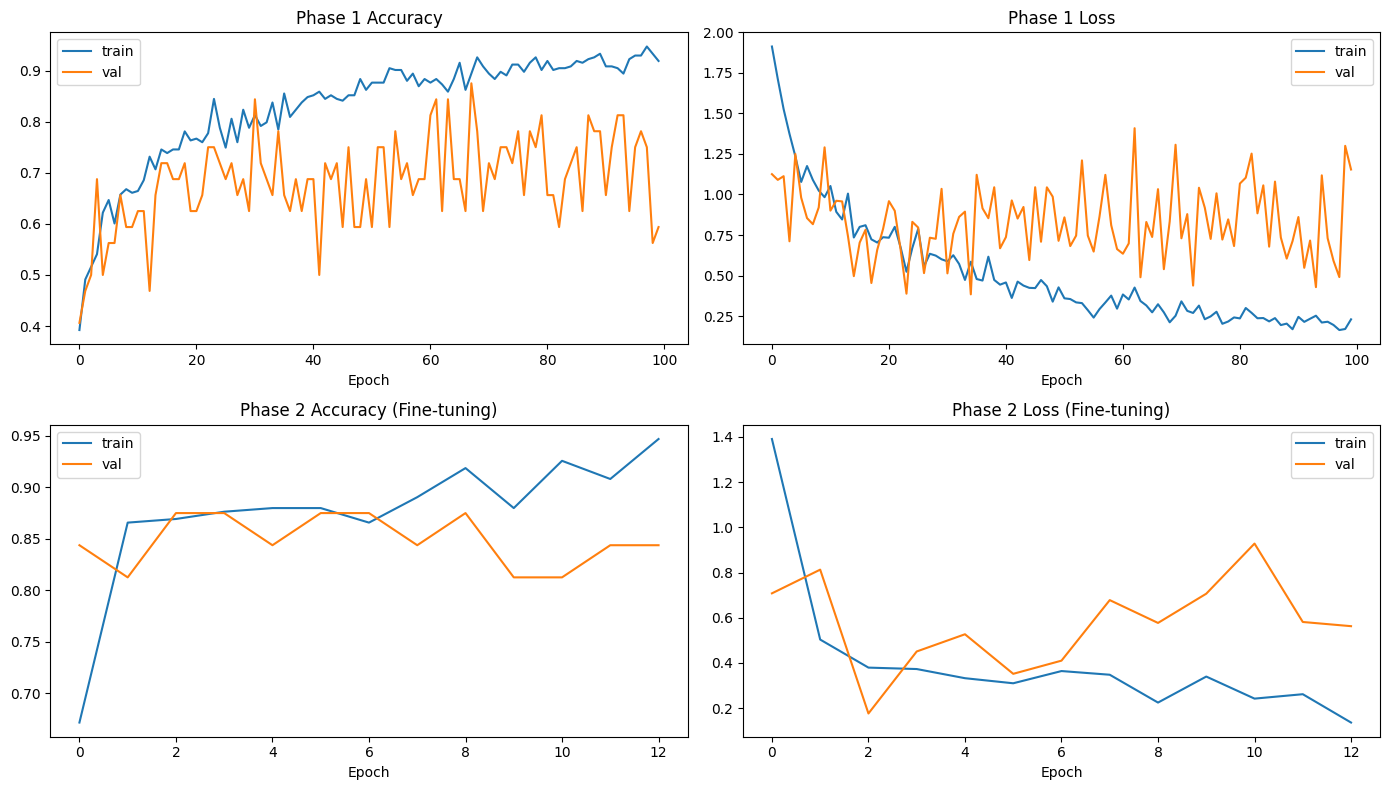

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Phase 1
axes[0, 0].plot(history.history["accuracy"], label="train")
axes[0, 0].plot(history.history["val_accuracy"], label="val")
axes[0, 0].set_title("Phase 1 Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(history.history["loss"], label="train")
axes[0, 1].plot(history.history["val_loss"], label="val")
axes[0, 1].set_title("Phase 1 Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

# Phase 2
axes[1, 0].plot(history_fine.history["accuracy"], label="train")
axes[1, 0].plot(history_fine.history["val_accuracy"], label="val")
axes[1, 0].set_title("Phase 2 Accuracy (Fine-tuning)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()

axes[1, 1].plot(history_fine.history["loss"], label="train")
axes[1, 1].plot(history_fine.history["val_loss"], label="val")
axes[1, 1].set_title("Phase 2 Loss (Fine-tuning)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [33]:
y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(preds, axis=1))

print("=== Phase 2 (Fine-tuned) ===")
print(classification_report(y_true_ft, y_pred_ft, target_names=CLASS_NAMES))

=== Phase 2 (Fine-tuned) ===
              precision    recall  f1-score   support

       candy       0.50      0.62      0.56         8
   chocolate       0.80      0.80      0.80        10
  rice_snack       0.94      0.85      0.89        20

    accuracy                           0.79        38
   macro avg       0.75      0.76      0.75        38
weighted avg       0.81      0.79      0.80        38



In [34]:
model.save("snack_classifier_fine_tuned.keras")
print("Fine-tuned model saved")

Fine-tuned model saved
